In [1]:
import torch
from deepod.models.time_series import TranAD

from utils.data_loader import load_volvo, load_optuna_val
from utils.evaluation import evaluate_model, cross_validate
from utils.hyperparameter_search import run_optuna_study

result_path="../Results/Volvo TranAD"

In [2]:
x_train, y_train, x_test, y_test, timestamps_train, timestamps_test, df_train, df_test = load_volvo(
    "../Dataset/Processed Dataset/volvoTrain.csv",
    "../Dataset/Processed Dataset/volvoTest.csv"
)

In [3]:
hyperparameters = {
    "lr": ("categorical", [1e-4, 1e-3, 1e-2]),
    "epochs": ("int", 2, 10, False),
    "epoch_steps": ("int", 10, 40, False),
}

df_train_optuna = load_optuna_val(df_train)

study = run_optuna_study(
    model_class=TranAD,
    hyperparameters=hyperparameters,
    train_df=df_train_optuna,
    validation_ratio=0.20,
    n_trials=10,
    study_name="tranad_optuna_study",
    storage="sqlite:///tranad_optuna.db"
)

print("Best params:", study.best_params)
print("Best validation score:", study.best_value)
print("Best trial extra metrics:", study.best_trial.user_attrs)

Optuna start:  2025-12-07 00:00:00.815694+00:00
Optuna end:  2025-12-10 12:43:09.072558+00:00


[I 2026-04-13 09:40:11,549] A new study created in RDB with name: tranad_optuna_study


Epoch 1,	 L1 = 0.7110762502998114
Epoch 2,	 L1 = 0.6483756089583039
Epoch 3,	 L1 = 0.7782227359712124
Epoch 4,	 L1 = 0.30258978763595223
Epoch 5,	 L1 = 0.5080684823915362
Epoch 6,	 L1 = 0.5073103210888803
Epoch 7,	 L1 = 0.44004675652831793


[I 2026-04-13 09:41:16,938] Trial 0 finished with value: 0.15926582597578323 and parameters: {'lr': 0.001, 'epochs': 7, 'epoch_steps': 14}. Best is trial 0 with value: 0.15926582597578323.


Epoch 1,	 L1 = 0.4950917166742412
Epoch 2,	 L1 = 0.42190376274061925
Epoch 3,	 L1 = 0.5130238223708037
Epoch 4,	 L1 = 0.3923402618278157
Epoch 5,	 L1 = 0.9085862155665051
Epoch 6,	 L1 = 0.3681945346973159
Epoch 7,	 L1 = 0.4236035030899626


...

Epoch 1,	 L1 = 0.6817597031593323
Epoch 2,	 L1 = 0.5827652350068092
Epoch 3,	 L1 = 0.6859762459993363
Epoch 4,	 L1 = 0.3887694180011749
Epoch 5,	 L1 = 0.5948118362575769
Epoch 6,	 L1 = 0.442298398911953
Epoch 7,	 L1 = 0.45059149861335757
Epoch 8,	 L1 = 0.4103208281099796
Epoch 9,	 L1 = 0.5920438177883625
Epoch 10,	 L1 = 0.5415686998516321


[I 2026-04-13 09:49:56,535] Trial 8 finished with value: 0.15927341497388153 and parameters: {'lr': 0.001, 'epochs': 10, 'epoch_steps': 18}. Best is trial 5 with value: 0.16328725727394927.


Epoch 1,	 L1 = 0.7174552451161778
Epoch 2,	 L1 = 0.6802739457172506
Epoch 3,	 L1 = 0.8137263883562649
Epoch 4,	 L1 = 0.44840968181105223
Epoch 5,	 L1 = 0.6120612112914815
Epoch 6,	 L1 = 0.6310534415876164


[I 2026-04-13 09:51:00,110] Trial 9 finished with value: 0.16332489636230257 and parameters: {'lr': 0.0001, 'epochs': 6, 'epoch_steps': 15}. Best is trial 9 with value: 0.16332489636230257.


Best params: {'lr': 0.0001, 'epochs': 6, 'epoch_steps': 15}
Best validation score: 0.16332489636230257
Best trial extra metrics: {'pr_auc': 0.16332489636230257}


In [4]:
# Cross validation
best_params = study.best_params
static_params = {
    "seq_len": 50,
    "stride": 5,
}

params = best_params | static_params

cross_val_scores = cross_validate(train_df=df_train, model=TranAD, params=params, result_path=result_path)
print(cross_val_scores)

Fold 1 start:  2025-11-26 00:00:06.255619+00:00
Fold 1 end:  2025-11-30 23:59:58.911052+00:00
Fold 2 start:  2025-11-26 00:00:06.255619+00:00
Fold 2 end:  2025-12-10 12:43:09.072558+00:00
model 1 params:  {'model_name': 'TranAD', 'data_type': 'ts', 'network': 'MLP', 'seq_len': 50, 'stride': 5, 'epochs': 6, 'batch_size': 128, 'lr': 0.0001, 'device': 'cuda', 'contamination': 0.1, 'epoch_steps': 15, 'prt_steps': 1, 'verbose': 2, 'n_features': None, 'n_samples': -1, 'criterion': None, 'net': None, 'n_ensemble': 1, 'train_loader': None, 'test_loader': None, 'epoch_time': None, 'train_data': None, 'train_label': None, 'decision_scores_': None, 'labels_': None, 'threshold_': None, 'random_state': 42, 'model': None, 'optimizer': None, 'scheduler': None, 'w_size': None} 

model 2 params:  {'model_name': 'TranAD', 'data_type': 'ts', 'network': 'MLP', 'seq_len': 50, 'stride': 5, 'epochs': 6, 'batch_size': 128, 'lr': 0.0001, 'device': 'cuda', 'contamination': 0.1, 'epoch_steps': 15, 'prt_steps': 1

In [5]:
model = TranAD(**params)
model.fit(x_train)

Epoch 1,	 L1 = 0.6590395552270553
Epoch 2,	 L1 = 0.5631505189573064
Epoch 3,	 L1 = 0.8798283487558365
Epoch 4,	 L1 = 0.5013613455435809
Epoch 5,	 L1 = 0.48143408666638765
Epoch 6,	 L1 = 0.7555551520165276


In [6]:
scores = model.decision_function(x_test)

# Utils results

{'roc_auc': 0.5924926253554483, 'pr_auc': 0.021034486719143642, 'f1': 0.03571428571428571}


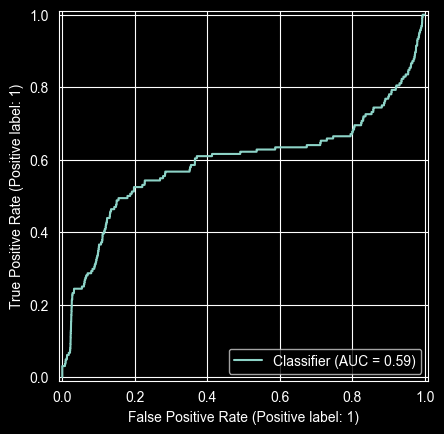

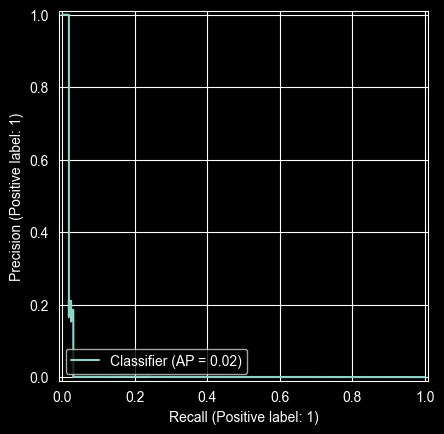

In [7]:
results = evaluate_model(y_test, scores, threshold=cross_val_scores["mean_threshold"], result_path=result_path)
print(results)

In [8]:
import pandas as pd
import os
df = pd.DataFrame(scores, columns=["score"])
scores_path = os.path.join(result_path, "scores.csv")
df.to_csv(scores_path, index=False)